LFC columns: ['log2FoldChange_rep1', 'log2FoldChange_rep2', 'log2FoldChange_rep3']
SE columns: ['lfcSE_rep1', 'lfcSE_rep2', 'lfcSE_rep3']


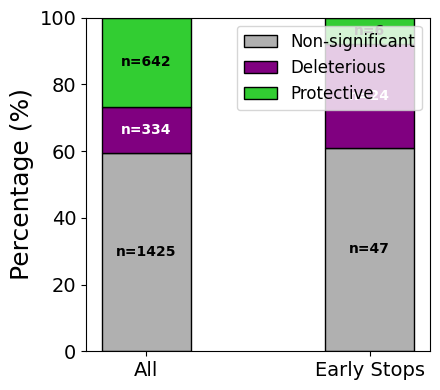

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') 
                   and c[-1] in ['1', '2', '3']])
se_cols = sorted([c for c in df1.columns if c.startswith('lfcSE_rep') 
                  and c[-1] in ['1', '2', '3']])

print(f"LFC columns: {lfc_cols}")
print(f"SE columns: {se_cols}")

# Extract data
lfc_data = df1[lfc_cols].values
se_data = df1[se_cols].values

# Calculate inverse-variance weights
weights = 1 / (se_data ** 2)

# Weighted mean LFC
weighted_lfc = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)

# Pooled SE of weighted mean
pooled_se = 1 / np.sqrt(np.nansum(weights, axis=1))

# Z-score and p-values
z_scores = weighted_lfc / pooled_se
pvalues = 2 * stats.norm.sf(np.abs(z_scores))

# Add to dataframe
df1['weighted_log2FC'] = weighted_lfc
df1['pooled_SE'] = pooled_se
df1['z_score'] = z_scores
df1['pvalue'] = pvalues

# Multiple testing correction
valid_mask = np.isfinite(df1['pvalue'])
_, padj_values, _, _ = multipletests(df1.loc[valid_mask, 'pvalue'], method='fdr_bh')
df1['padj'] = np.nan
df1.loc[valid_mask, 'padj'] = padj_values
df1['neg_log10_padj'] = -np.log10(df1['padj'])

# Identify early stops
early_stops = df1[df1['Sequence_ID'].str.endswith('_early_stop')].copy()

# Counts for entire library (All)
all_ns = len(df1[df1['neg_log10_padj'] <= -np.log10(0.05)])
all_protect = len(df1[(df1['neg_log10_padj'] > -np.log10(0.05)) & (df1['weighted_log2FC'] > 0)])
all_delet = len(df1[(df1['neg_log10_padj'] > -np.log10(0.05)) & (df1['weighted_log2FC'] < 0)])
all_total = all_ns + all_protect + all_delet

# Counts for early stops
es_ns = len(early_stops[early_stops['neg_log10_padj'] <= -np.log10(0.05)])
es_protect = len(early_stops[(early_stops['neg_log10_padj'] > -np.log10(0.05)) & (early_stops['weighted_log2FC'] > 0)])
es_delet = len(early_stops[(early_stops['neg_log10_padj'] > -np.log10(0.05)) & (early_stops['weighted_log2FC'] < 0)])
es_total = es_ns + es_protect + es_delet

# Convert to percentages
all_ns_pct = all_ns / all_total * 100
all_protect_pct = all_protect / all_total * 100
all_delet_pct = all_delet / all_total * 100

es_ns_pct = es_ns / es_total * 100
es_protect_pct = es_protect / es_total * 100
es_delet_pct = es_delet / es_total * 100

fig, ax = plt.subplots(figsize=(4.5, 4))

x = ["All", "Early Stops"]
width = 0.4

# Non-significant (bottom)
ax.bar(x, [all_ns_pct, es_ns_pct], 
       label="Non-significant", color="#b0b0b0", edgecolor='black', width=width)

# Deleterious (middle)
ax.bar(x, [all_delet_pct, es_delet_pct], 
       bottom=[all_ns_pct, es_ns_pct],
       label="Deleterious", color="purple", edgecolor='black', width=width)

# Protective (top)
ax.bar(x, [all_protect_pct, es_protect_pct], 
       bottom=[all_ns_pct + all_delet_pct, es_ns_pct + es_delet_pct],
       label="Protective", color="limegreen", edgecolor='black', width=width)

# Add N labels on each segment
# Non-significant labels (center of bottom segment)
ax.text(0, all_ns_pct/2, f'n={all_ns}', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1, es_ns_pct/2, f'n={es_ns}', ha='center', va='center', fontsize=10, fontweight='bold')

# Deleterious labels (center of middle segment)
ax.text(0, all_ns_pct + all_delet_pct/2, f'n={all_delet}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.text(1, es_ns_pct + es_delet_pct/2, f'n={es_delet}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Protective labels (center of top segment)
ax.text(0, all_ns_pct + all_delet_pct + all_protect_pct/2, f'n={all_protect}', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(1, es_ns_pct + es_delet_pct + es_protect_pct/2, f'n={es_protect}', ha='center', va='center', fontsize=10, fontweight='bold')

ax.set_ylabel("Percentage (%)", fontsize=18)
ax.set_ylim(0, 100)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('comparison_plot_early_stops_weighted.svg', format='svg', bbox_inches='tight')
plt.show()
